In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import sqlite3

## Fright Cost 
   #### means goods transport cost

In [6]:
conn = sqlite3.connect(r"C:\Users\User\Desktop\ML project\Data\inventory.db")
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'",conn)

In [8]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [9]:
for table in tables['name']:
    print("table_name ",table)
    df = pd.read_sql_query(f"select * from {table} limit 5",conn)
    display(df)
    

table_name  purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


table_name  purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


table_name  vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


table_name  begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


table_name  end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [10]:
vendore_df = pd.read_sql_query("select * from vendor_invoice ", conn)

In [13]:
vendore_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [15]:
vendore_df[["Quantity", "Dollars","Freight"]].corr()

,Quantity,Dollars,Freight
Quantity,1.000000,0.963831,0.946550
Dollars,0.963831,1.000000,0.985141
Freight,0.946550,0.985141,1.000000


In [16]:
re = vendore_df[["Quantity", "Dollars","Freight"]].corr()

<Axes: >

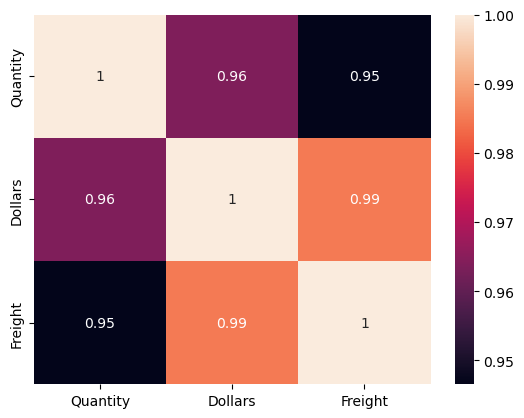

In [18]:
sns.heatmap(re,annot=True,
    fmt='.2g')

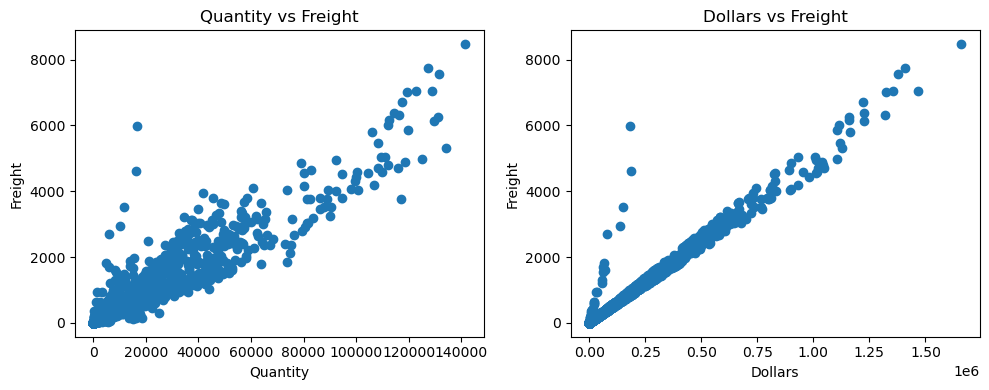

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Plot 1
plt.subplot(1,2,1)
plt.scatter(vendore_df["Quantity"], vendore_df["Freight"])
plt.xlabel("Quantity")
plt.ylabel("Freight")
plt.title("Quantity vs Freight")

# Plot 2
plt.subplot(1,2,2)
plt.scatter(vendore_df["Dollars"], vendore_df["Freight"])
plt.xlabel("Dollars")
plt.ylabel("Freight")
plt.title("Dollars vs Freight")

plt.tight_layout()
plt.show()


In [21]:
vendore_df['freight_per_unit'] = vendore_df['Freight']/vendore_df['Quantity']

In [26]:
low_qantity = vendore_df['Quantity'].quantile(0.25)
high_qantity = vendore_df['Quantity'].quantile(0.75)

In [24]:
low_qantity

83.0

In [27]:
high_qantity

5100.5

In [34]:
vendore_df.loc[vendore_df['Quantity']<low_qantity,'freight_per_unit'].mean()

0.09489854253138316

In [35]:
vendore_df.loc[vendore_df['Quantity']>high_qantity,'freight_per_unit'].mean()

0.049077654690759046

In [36]:
X= vendore_df[["Quantity", "Dollars"]]
y = vendore_df["Freight"]

In [38]:
from sklearn.model_selection import train_test_split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
X_train

,Quantity,Dollars
2609,24,264.24
5527,36,342.48
5321,30,572.40
3805,10721,68821.14
1215,80495,604197.73
...,...,...
3772,161,2618.27
5191,6879,74386.98
5226,6,36.96
5390,80,644.00


In [44]:
# Linear Regression
from sklearn.linear_model import LinearRegression

# Random Forest
from sklearn.ensemble import RandomForestRegressor

# XGBoost
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [45]:
# Train models
lr = LinearRegression()
rf = RandomForestRegressor()
xgb = XGBRegressor()

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [46]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Model: {model.__class__.__name__}")
    print("MSE:", mse)
    print("MAE:", mae)
    print("R2:", r2)
    print("-"*30)

In [50]:
evaluate_model(lr, X_test, y_test)

Model: LinearRegression
MSE: 15482.522464835094
MAE: 24.45918076526339
R2: 0.9700197330175596
------------------------------


In [51]:
evaluate_model(rf, X_test, y_test)

Model: RandomForestRegressor
MSE: 19151.68360718524
MAE: 27.663521386267508
R2: 0.9629147905962521
------------------------------


In [52]:
evaluate_model(xgb, X_test, y_test)

Model: XGBRegressor
MSE: 25756.170531575426
MAE: 28.01104732124412
R2: 0.9501259003023756
------------------------------


In [55]:
y_test.size

1109

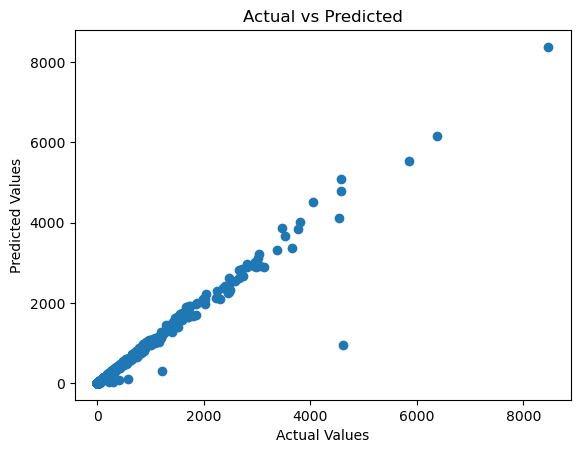

In [64]:
y_pred = lr.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()